### FashionMNIST - GAN 사용

### 1) 

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, utils
from torchvision.utils import save_image
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2
import time
gpu = ('cuda:0')

100%|██████████| 26421880/26421880 [00:01<00:00, 15930540.87it/s]


Extracting dataset/FashionMNIST/raw/train-images-idx3-ubyte.gz to dataset/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 271765.48it/s]


Extracting dataset/FashionMNIST/raw/train-labels-idx1-ubyte.gz to dataset/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 5043131.77it/s]


Extracting dataset/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to dataset/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 6595075.44it/s]


Extracting dataset/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to dataset/FashionMNIST/raw

torch.Size([32, 1, 32, 32])
torch.Size([32])
Labels : tensor([0, 5, 9, 3, 0, 6, 1, 5, 7, 9, 3, 1, 1, 0, 7, 2, 1, 3, 1, 6, 7, 5, 4, 2,
        8, 8, 5, 9, 8, 0, 9, 2])


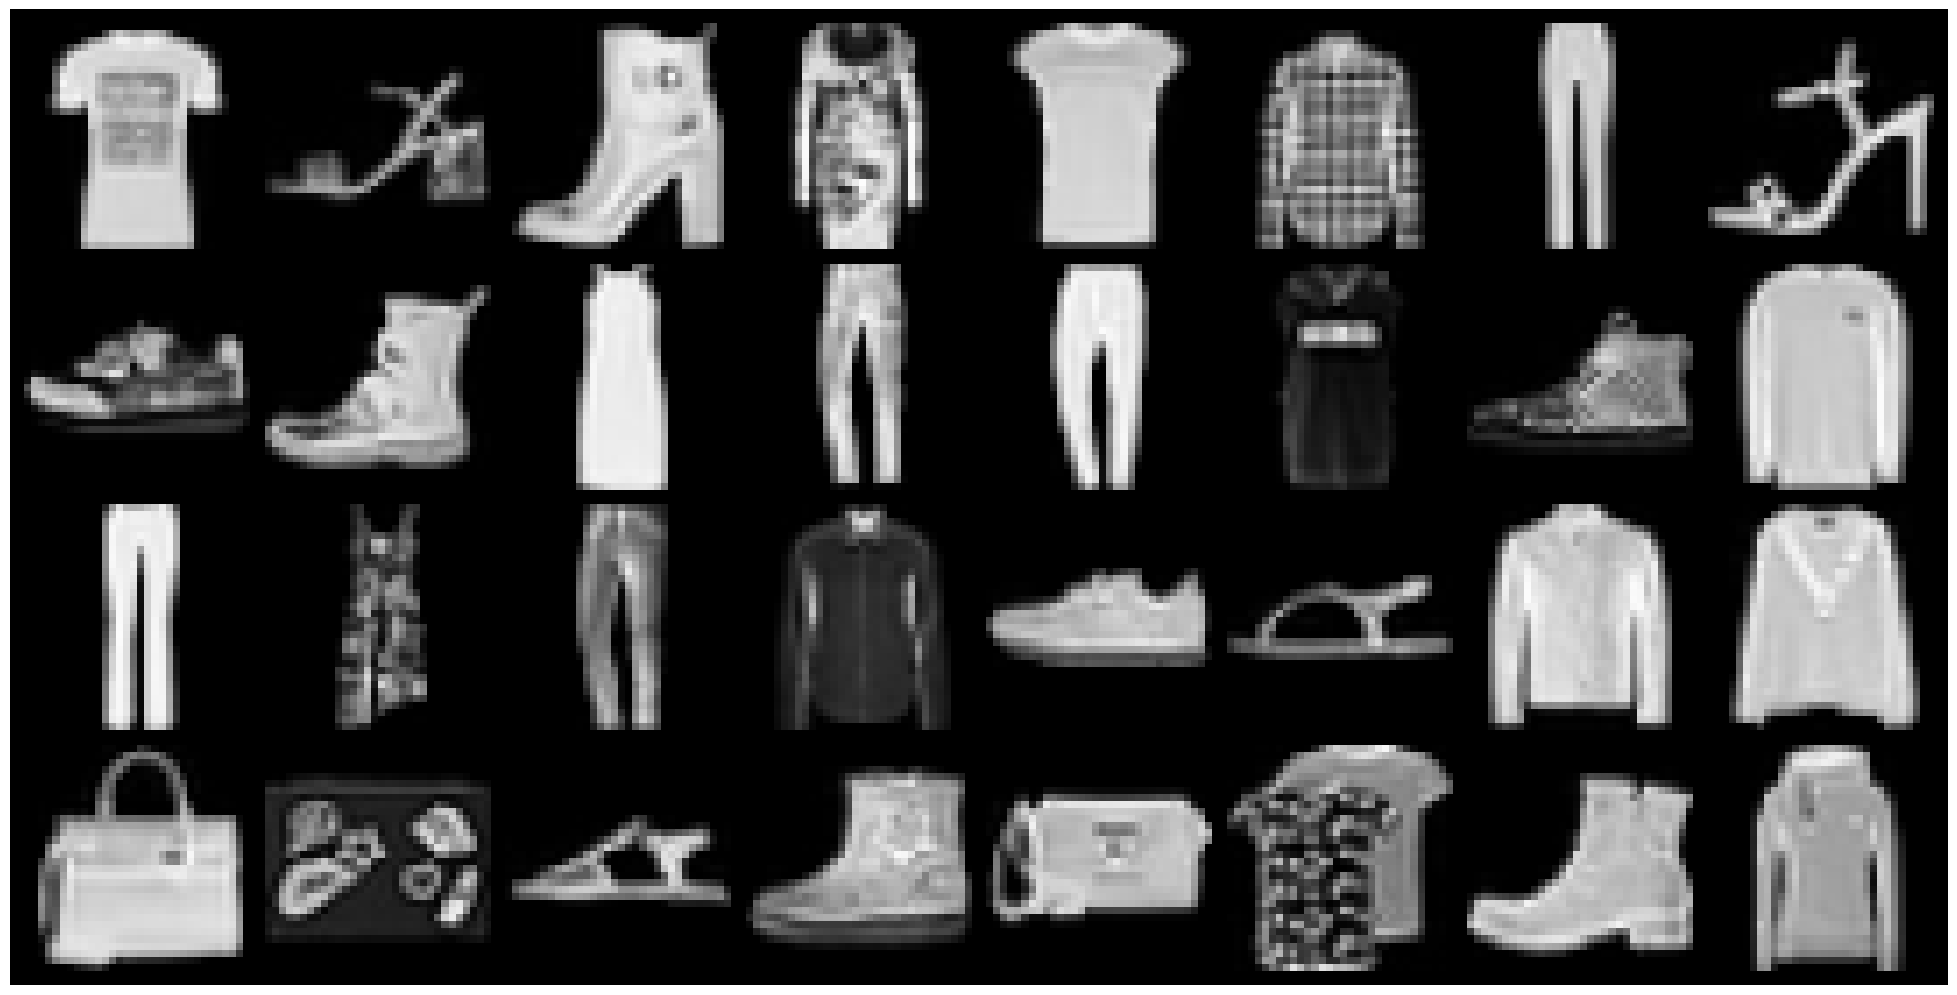

In [ ]:
_transforms = transforms.Compose([
    transforms.Resize((32, 32))
    ,transforms.ToTensor()
    ])
_dataset = datasets.FashionMNIST(root='dataset/', train=True, transform=_transforms, download=True)
_dataloader = DataLoader(_dataset, batch_size=32, shuffle=True)
_batch = next(iter(_dataloader))
_images, _labels = _batch
print(_images.shape)
print(_labels.shape)

grid = utils.make_grid(_images, nrow = 8)

plt.figure(figsize = (25,25))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis('off')
print("Labels :", _labels)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_channels, feature_maps):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            # in 1*32*32
            nn.Conv2d(img_channels, feature_maps, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            # in 16*16*16
            nn.Conv2d(feature_maps, feature_maps*2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(feature_maps*2),
            nn.LeakyReLU(0,2),
            # in 32*8*8
            nn.Conv2d(feature_maps*2, feature_maps*4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(feature_maps*4),
            nn.LeakyReLU(0,2),
            # in 64*4*4
            nn.Conv2d(feature_maps*4, 1, kernel_size=4, stride=2, padding=0),
            nn.Sigmoid()
            # out 1*1
            )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_channels, img_channels, feature_maps):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            # in 256*1*1
            nn.ConvTranspose2d(noise_channels, feature_maps*16, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(feature_maps*16),
            nn.ReLU(),  
            # in 256*4*4  
            nn.ConvTranspose2d(feature_maps*16, feature_maps*8, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(feature_maps*8),
            nn.ReLU(),
            # in 128*8*8  
            nn.ConvTranspose2d(feature_maps*8, feature_maps*4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(feature_maps*4),
            nn.ReLU(),
            # in 64*16*16
            nn.ConvTranspose2d(feature_maps*4, img_channels, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
            # out 1*32*32
            )

    def forward(self, x):
        return self.net(x)

In [ ]:
discriminator = Discriminator(1, 16).to(gpu)
print(discriminator)

Discriminator(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0, inplace=True)
    (5): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0, inplace=True)
    (8): Conv2d(64, 1, kernel_size=(4, 4), stride=(2, 2))
    (9): Sigmoid()
  )
)


In [ ]:
generetor = Generator(256, 1, 16).to(gpu)
print(generetor)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU()
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): Tanh()
  )
)


In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((32, 32))
    ,transforms.ToTensor()
    ,transforms.Normalize((0.5), (0.5))
])

dataset = datasets.FashionMNIST(root='dataset/', train=True, transform=train_transforms, download=True)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=1, pin_memory=True)

print("Number of Classes : ", len(dataset.class_to_idx))
print("Classes : ", dataset.class_to_idx)
print("Number of Training Samples : ", len(dataset))

Number of Classes :  10
Classes :  {'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
Number of Training Samples :  60000


In [ ]:
optim_d = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optim_g = torch.optim.Adam(generetor.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

In [ ]:
loss_discriminator = []
loss_generator = []

for epoch in range(30):

    t0 = time.time()
    running_loss_d = 0.0
    running_loss_g = 0.0
    discriminator.train()
    generetor.train()

    for images, _ in dataloader:
        images = images.to(gpu)
        batch_size = images.shape[0]

        discriminator.zero_grad()
        labels = (torch.ones(batch_size)*0.9).to(gpu)
        out = discriminator(images).reshape(-1)
        loss_d_real = criterion(out, labels)

        noise = torch.randn(batch_size, 256, 1, 1).to(gpu)
        fake_imgs = generetor(noise)
        labels = (torch.ones(batch_size)*0.1).to(gpu)
        out = discriminator(fake_imgs.detach()).reshape(-1)
        loss_d_fake = criterion(out, labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        optim_d.step()

        running_loss_d += loss_d.item()

        generetor.zero_grad()
        labels = torch.ones(batch_size).to(gpu)
        out = discriminator(fake_imgs).reshape(-1)
        loss_g = criterion(out, labels)
        loss_g.backward()
        optim_g.step()

        running_loss_g += loss_g.item()

    epoch_loss_d = running_loss_d/len(dataloader.dataset)*2
    epoch_loss_g = running_loss_g/len(dataloader.dataset)
    loss_discriminator.append(epoch_loss_d)
    loss_generator.append(epoch_loss_g)
    
    print('----------------------------------------------------------------')
    print('epoch: ', (epoch + 1))   
    print('----------------------------------------------------------------')
    print('discriminator loss: {:.4f}'.format(epoch_loss_d))
    print('generator loss: {:.4f}'.format(epoch_loss_g))
    print('epoch time: {:.4f} seconds'.format(time.time() - t0))

    checkpoint = {
        'epoch': epoch + 1
        ,'gen_state_dict': generetor.state_dict()
        ,'gen_optimizer' : optim_g.state_dict()
        ,'gen_loss' : epoch_loss_g
        ,'list_gen_loss' : loss_generator
        ,'disc_state.dict' : discriminator.state_dict()
        ,'disc_optimizer' : optim_d.state_dict()
        ,'disc_loss' : epoch_loss_d
        ,'list_disc_loss' : loss_discriminator
        }
    
    torch.save(checkpoint, f'/content/checkpoint/gans_fashionmnist_epoch_{epoch + 1}.pth')

    fake_imgs = fake_imgs.reshape(-1, 1, 32, 32)
    fake_imgs = (fake_imgs + 1) / 2
    save_image(fake_imgs, '/content/test/fake images epoch {}.png'.format(epoch + 1))
     


----------------------------------------------------------------
epoch:  1
----------------------------------------------------------------
discriminator loss: 0.0646
generator loss: 0.0416
epoch time: 33.6112 seconds
----------------------------------------------------------------
epoch:  2
----------------------------------------------------------------
discriminator loss: 0.0592
generator loss: 0.0476
epoch time: 33.2892 seconds
----------------------------------------------------------------
epoch:  3
----------------------------------------------------------------
discriminator loss: 0.0532
generator loss: 0.0557
epoch time: 33.4688 seconds
----------------------------------------------------------------
epoch:  4
----------------------------------------------------------------
discriminator loss: 0.0493
generator loss: 0.0627
epoch time: 32.8403 seconds
----------------------------------------------------------------
epoch:  5
-----------------------------------------------------

In [ ]:
# load checkpoint 
checkpoint = torch.load('/content/checkpoint/gans_fashionmnist_epoch_30.pth')

last_epoch = checkpoint['epoch']

generetor.load_state_dict(checkpoint['gen_state_dict'])
optim_g.load_state_dict(checkpoint['gen_optimizer'])
gen_loss_old = checkpoint['gen_loss']
list_gen_loss_old = checkpoint['list_gen_loss']

discriminator.load_state_dict(checkpoint['disc_state.dict'])
optim_d.load_state_dict(checkpoint['disc_optimizer'])
disc_loss_old = checkpoint['disc_loss']
list_disc_loss_old = checkpoint['list_disc_loss']

print('last epoch: {}'.format(last_epoch))
print('last discriminator loss: {:.4f}'.format(disc_loss_old))
print('last generator loss: {:.4f}'.format(gen_loss_old))

last epoch: 30
last discriminator loss: 0.0428
last generator loss: 0.0713


<ipython-input-15-3209f0d365ad>:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-darkgrid')


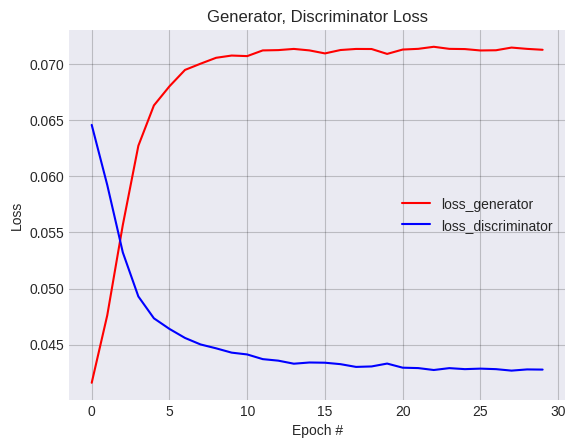

In [ ]:
plt.style.use('seaborn-darkgrid')
plt.figure()
plt.plot(list_gen_loss_old, color = 'red')
plt.plot(list_disc_loss_old, color = 'blue')
plt.title('Generator, Discriminator Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch #')
plt.legend(['loss_generator', 'loss_discriminator'], loc = 'center right')
plt.grid(axis = 'y', c = 'black', alpha = 0.2)
plt.grid(axis = 'x', c = 'black', alpha = 0.2)

(-0.5, 273.5, 137.5, -0.5)

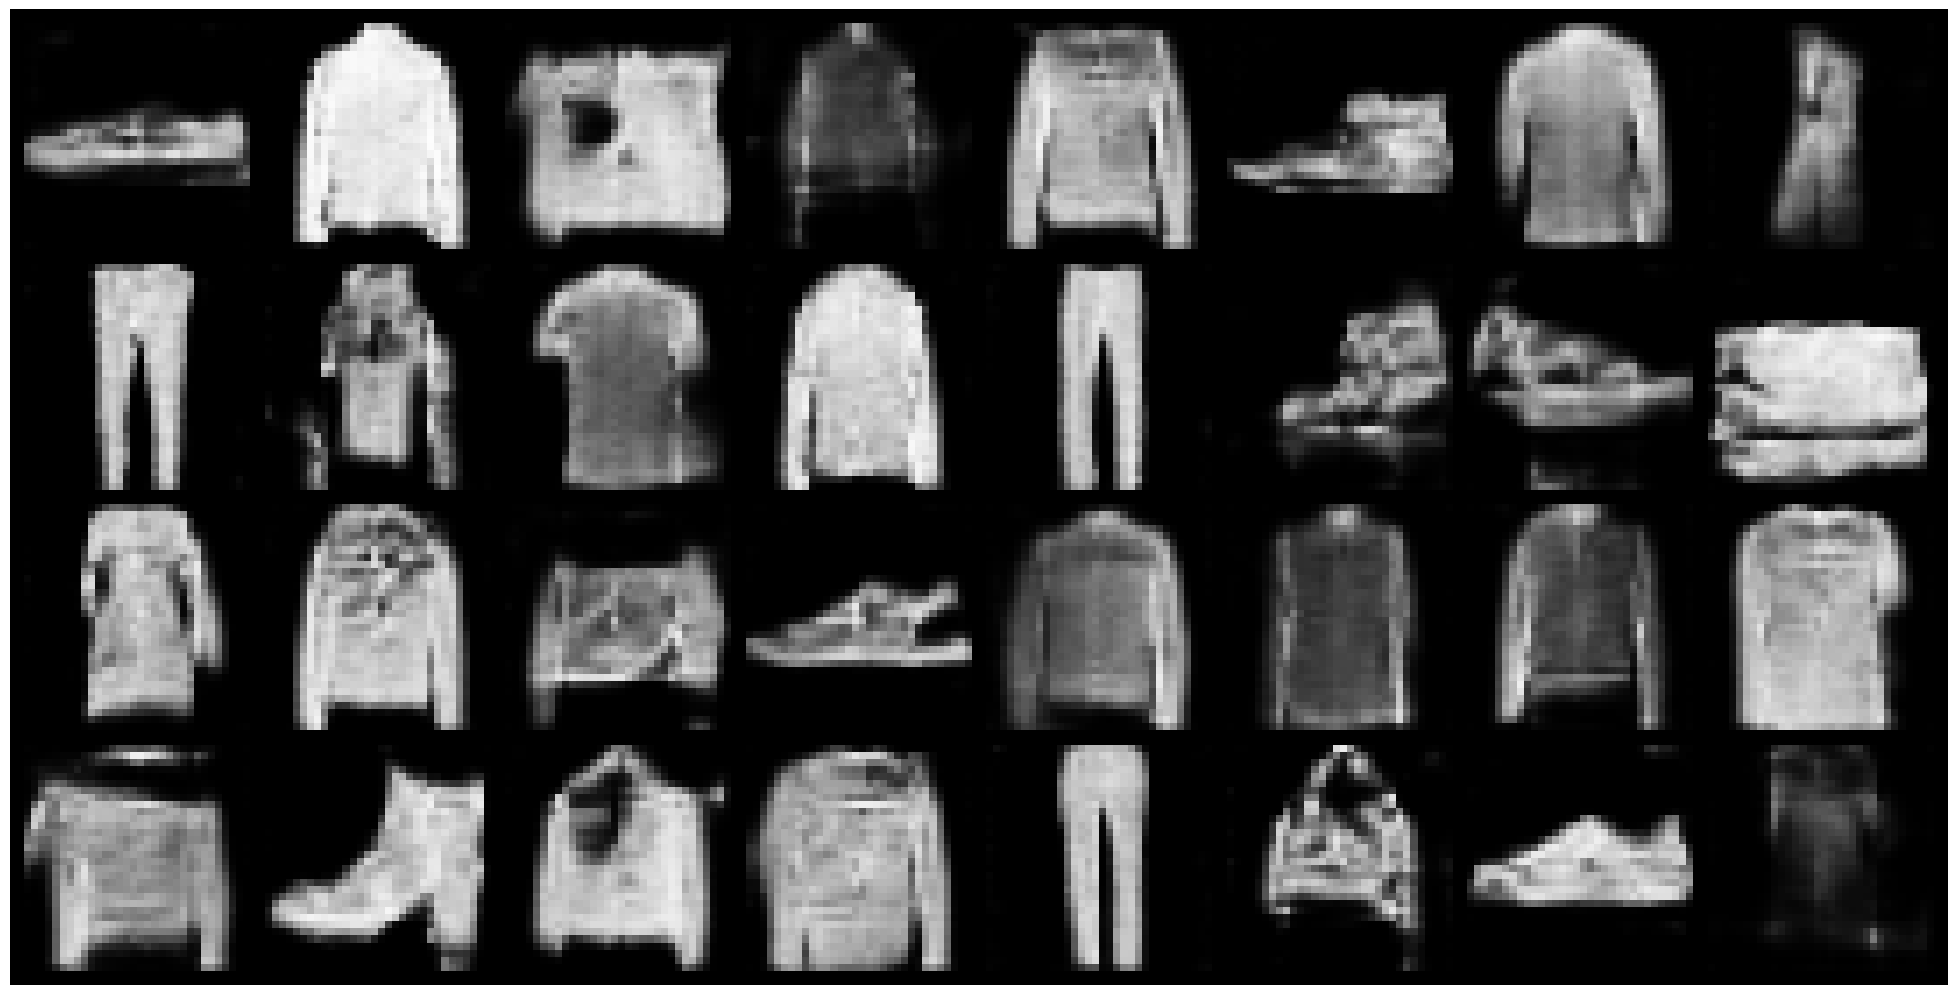

In [ ]:
noise = torch.randn(32, 256, 1, 1).to(gpu)
result = generetor(noise)
image = result.detach()
image = image.cpu()
image = (image + 1) / 2
grid = utils.make_grid(image, nrow = 8)
plt.figure(figsize = (25,25))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis('off')

### 2) 

In [ ]:
# 라이브러리
import torch
import random
import os
import numpy as np
import matplotlib.pyplot as plt

import torch.optim as optim
import torchvision.utils as utils
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
latent_size = 64
hidden_size = 256
image_size = 784   # 28 * 28
num_epochs = 300
batch_size = 100

transform = transforms.Compose([
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.5], # 1 for gray scale 만약, RGB channels라면 mean=(0.5, 0.5, 0.5)
                                         std=[0.5])])  # 1 for gray scale 만약, RGB channels라면 std=(0.5, 0.5, 0.5)

# MNIST dataset
mnist_train = datasets.FashionMNIST(root='MNIST_data/',
                          train=True,
                          transform=transform, 
                          download=True)

mnist_test = datasets.FashionMNIST(root='MNIST_data/',
                         train=False,
                         transform=transforms,
                         download=True)

100%|██████████| 26421880/26421880 [00:03<00:00, 8471984.09it/s] 


Extracting MNIST_data/FashionMNIST/raw/train-images-idx3-ubyte.gz to MNIST_data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 143714.75it/s]


Extracting MNIST_data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:01<00:00, 2663450.80it/s]


Extracting MNIST_data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 6102961.28it/s]

Extracting MNIST_data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/FashionMNIST/raw



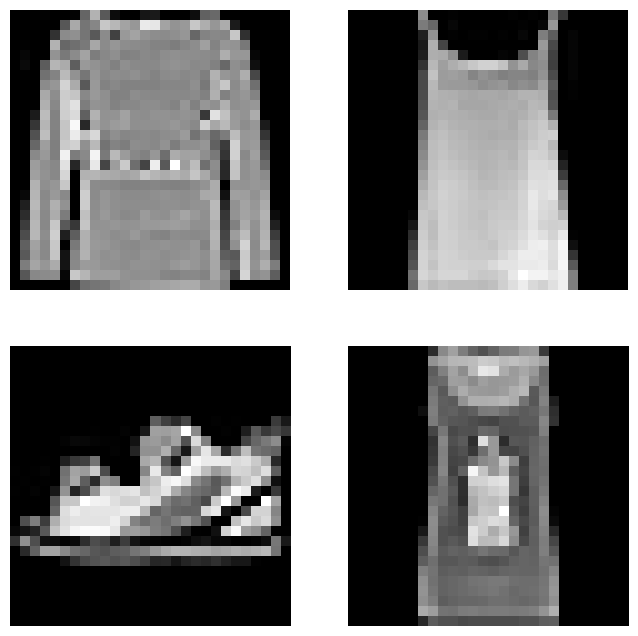

In [ ]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 2, 2
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
    img, label = mnist_train[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
data_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)                   

D = nn.Sequential(
    nn.Linear(image_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, hidden_size),
    nn.LeakyReLU(0.2),
    nn.Linear(hidden_size, 1),
    nn.Sigmoid()) # Binary Cross Entropy loss 를 사용할 것이기에 sigmoid 사용!

G = nn.Sequential(
    nn.Linear(latent_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, image_size),
    nn.Tanh())

D = D.to(device)
G = G.to(device)

In [ ]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(D.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(G.parameters(), lr=0.0002)

In [ ]:
def denorm(x):
    out = (x + 1) / 2
    return out.clamp(0, 1)

def reset_grad(): 
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

In [ ]:
dx_epoch = []
dgx_epoch = []
total_step = len(data_loader)
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        images = images.reshape(batch_size, -1).to(device)
        
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        outputs = D(images)
        d_loss_real = criterion(outputs, real_labels)
        real_score = outputs
        
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)
        d_loss_fake = criterion(outputs, fake_labels)
        fake_score = outputs
        
        d_loss = d_loss_real + d_loss_fake
        reset_grad()
        d_loss.backward()
        d_optimizer.step()
        
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = G(z)
        outputs = D(fake_images)
    
        g_loss = criterion(outputs, real_labels)
      
        reset_grad()
        g_loss.backward()
        g_optimizer.step()
        
        if (i+1) % 200 == 0:
            print('Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}' 
                  .format(epoch, num_epochs, i+1, total_step, d_loss.item(), g_loss.item(), 
                          real_score.mean().item(), fake_score.mean().item()))
    dx_epoch.append(real_score.mean().item())            
    dgx_epoch.append(fake_score.mean().item())

    if (epoch+1) == 1:
        images = images.reshape(images.size(0), 1, 28, 28)
        save_image(denorm(images), os.path.join(sample_dir, 'real_images.png'))

    fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
    save_image(denorm(fake_images), os.path.join(sample_dir, 'fake_images-{}.png'.format(epoch+1)))

torch.save(G.state_dict(), 'G.ckpt')
torch.save(D.state_dict(), 'D.ckpt')

Epoch [0/300], Step [200/600], d_loss: 0.0703, g_loss: 4.0859, D(x): 0.98, D(G(z)): 0.05
Epoch [0/300], Step [400/600], d_loss: 0.1834, g_loss: 4.8868, D(x): 0.96, D(G(z)): 0.12
Epoch [0/300], Step [600/600], d_loss: 0.0609, g_loss: 4.2219, D(x): 0.98, D(G(z)): 0.04
Epoch [1/300], Step [200/600], d_loss: 0.0606, g_loss: 4.1048, D(x): 0.98, D(G(z)): 0.03
Epoch [1/300], Step [400/600], d_loss: 0.0303, g_loss: 4.9432, D(x): 0.98, D(G(z)): 0.01
Epoch [1/300], Step [600/600], d_loss: 0.0140, g_loss: 5.7683, D(x): 0.99, D(G(z)): 0.01
Epoch [2/300], Step [200/600], d_loss: 0.0139, g_loss: 6.5112, D(x): 1.00, D(G(z)): 0.01
Epoch [2/300], Step [400/600], d_loss: 0.0224, g_loss: 6.2846, D(x): 0.99, D(G(z)): 0.02
Epoch [2/300], Step [600/600], d_loss: 0.0860, g_loss: 6.6934, D(x): 0.99, D(G(z)): 0.07
Epoch [3/300], Step [200/600], d_loss: 0.3432, g_loss: 5.4706, D(x): 0.92, D(G(z)): 0.03
Epoch [3/300], Step [400/600], d_loss: 0.1778, g_loss: 6.2877, D(x): 0.95, D(G(z)): 0.03
Epoch [3/300], Step [

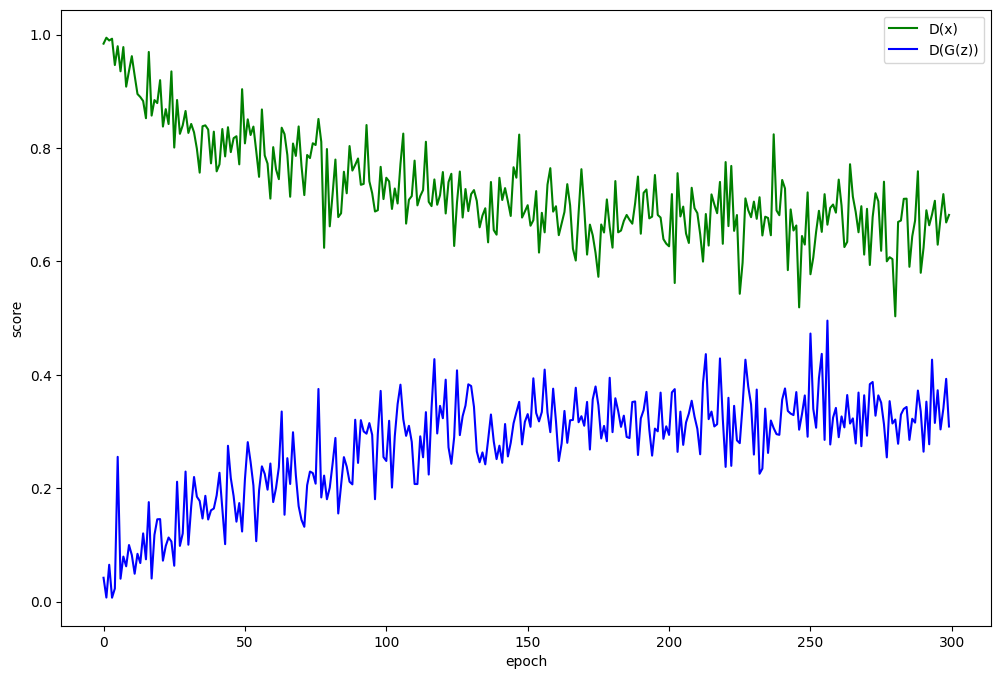

In [ ]:
plt.figure(figsize = (12, 8))
plt.xlabel('epoch')
plt.ylabel('score')
x = np.arange(num_epochs)
plt.plot(x, dx_epoch, 'g', label='D(x)')
plt.plot(x, dgx_epoch, 'b', label='D(G(z))')
plt.legend()
plt.show()